# F_antidromic_combined.ipynb

## Purpose
Identifies and characterizes antidromically-activated projection neurons across sessions. Applies a tiered classification system (tier 1: jitter, collision test, and antidromic response criteria; tier 2: looser thresholds) to classify PrL → subcortical projection neurons.

## Manuscript figure panels
- FigA12

## Prerequisites
Before running this notebook, ensure the figure preparation scripts have been run in sequence (see `/root/capsule/code/beh_ephys_analysis/session_combine/figure_preparation/sequence`).

Required input files:
- `combined_unit_tbl.pkl` (Step 1)
- `combined_antidromic_tbl.pkl` (Step 2)

In [1]:
# Standard library
import os
import sys
import re
import json
import pickle
import glob
import ast
import warnings
from pathlib import Path
import importlib

# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
import pathlib

# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
try:
    _here = pathlib.Path(__file__).resolve().parent          # script mode
except NameError:
    try:
        _here = pathlib.Path(__vsc_ipynb_file__).resolve().parent  # VS Code notebook
    except NameError:
        _here = pathlib.Path(os.getcwd())                    # other Jupyter fallback

_beh_ephys_root = str((_here / '../..').resolve())
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)
# Scientific libraries
import numpy as np
import pandas as pd
import xarray as xr
import scipy.signal as signal
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import colormaps
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# SpikeInterface
import spikeinterface.full as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.postprocessing as spost
import spikeinterface.widgets as sw

# Progress bar
from tqdm import tqdm
import seaborn as sns
from trimesh import load_mesh

# IPython display
from IPython.display import clear_output

# Open Ephys
from open_ephys.analysis import Session

# AIND analysis and utils
from aind_dynamic_foraging_basic_analysis.licks.lick_analysis import load_nwb
from aind_dynamic_foraging_data_utils.nwb_utils import load_nwb_from_filename
from aind_ephys_utils import align, sort

# Local utilities
import utils.analysis_funcs as af
import utils.plotting_funcs as pf
from utils.beh_functions import session_dirs
from utils.combine_tools import apply_qc
from utils.ccf_utils import pir_to_lps, project_to_plane
from utils.plot_utils import combine_pdf_big
from utils.capsule_migration import capsule_directories

import k3d
from scipy.stats import pearsonr

# Matplotlib inline for Jupyter
%matplotlib inline
capsule_dirs = capsule_directories()
from utils.capsule_migration import CAPSULE_ROOT
from utils.panel_utils import save_panels, save_panel_csv, columns_to_df, heatmap_to_df


# Pack data

In [2]:
criteria_name = 'basic_ephys'

In [3]:
# load constraints and data
with open(os.path.join(capsule_dirs['manuscript_fig_prep_dir'], 'combined_unit_tbl', 'combined_unit_tbl.pkl'), 'rb') as f:
    combined_tagged_units = pickle.load(f)
    
with open(os.path.join(CAPSULE_ROOT + '/code/beh_ephys_analysis/session_combine/metrics', f'{criteria_name}.json'), 'r') as f:
    constraints = json.load(f)
    
# beh_folder = os.path.join(str(capsule_directories()['derived_dir']) + '/combined/beh_plots', criteria_name)
target_folder = f'{capsule_dirs["manuscript_fig_dir"]}/F_antidromic/'
beh_folder = f'{capsule_dirs["manuscript_fig_prep_dir"]}/antidromic_analysis/'
if not os.path.exists(target_folder):
    os.makedirs(target_folder)
# start with a mask of all True
mask = pd.Series(True, index=combined_tagged_units.index)

Applying bounds for isi_violations: [0.0, 0.2]
 - isi_violations: 15278 -> 7875 units passed
Applying items for qc_pass: [True]
 - qc_pass: 7875 -> 5399 units passed
Applying bounds for peak: [-1000, 500]
 - peak: 5399 -> 5368 units passed
Applying conditional bounds for y_loc
 - y_loc: 5368 -> 3770 units passed
Applying opto conditions: ['p_max', 'eu', 'corr', 'tag_loc', 'lat_max_p', 'p_mean', 'sig_counts']


Number of opto rows after filtering: 365
Number of non-opto rows after filtering: 3770


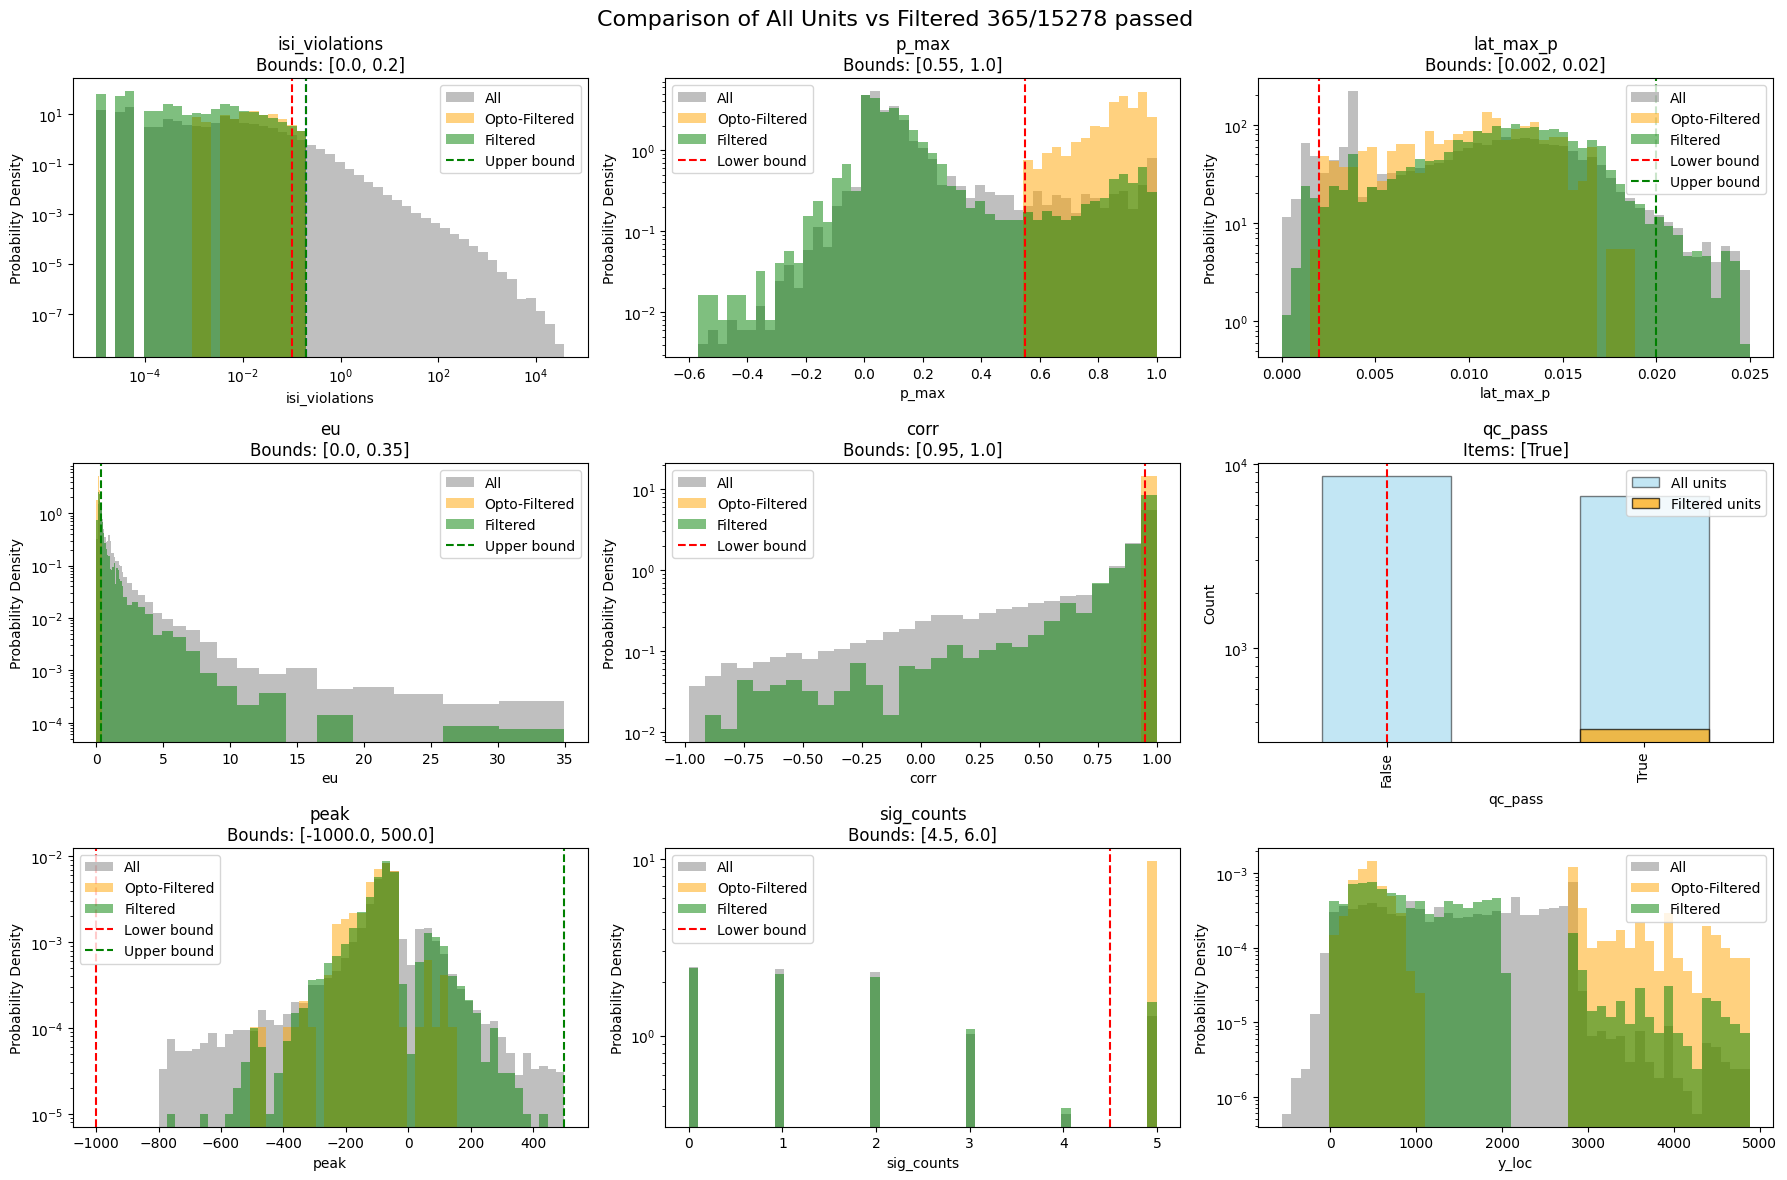

In [4]:
combined_tagged_units_filtered, combined_tagged_units, fig, axes = apply_qc(combined_tagged_units, constraints)
fig.savefig(os.path.join(target_folder, 'units_quality_metrics_summary.pdf'))

# Load antidromic units

In [5]:
session_list = combined_tagged_units_filtered[combined_tagged_units_filtered['probe']=='2']['session'].unique().tolist()
file = os.path.join(beh_folder, 'combined_antidromic_results.pkl')
print(f'Loading antidromic results from {file}')
with open(file, 'rb') as f:
    concatenate_antidromic_results = pickle.load(f)

Loading antidromic results from /root/capsule/scratch/results/manuscript/prep/antidromic_analysis/combined_antidromic_results.pkl


In [6]:
# if re_compute:
#     concatenate_antidromic_results_all = []
#     for session in session_list:
#         session_dir = session_dirs(session)
#         save_dir = os.path.join(session_dir['opto_dir_curated'], f'{session}_antidromic_results.pkl')
#         if os.path.exists(save_dir):
#             with open(save_dir, 'rb') as f:
#                 merged_df = pickle.load(f)
#             merged_df['session'] = session
#             concatenate_antidromic_results_all.append(merged_df)
#     concatenate_antidromic_results = pd.concat(concatenate_antidromic_results_all, ignore_index=True)
#     concatenate_antidromic_results.rename(columns={'unit_id': 'unit'}, inplace=True)
#     file = os.path.join(beh_folder, 'combined_antidromic_results.pkl')
#     with open(file, 'wb') as f:
#         pickle.dump(concatenate_antidromic_results, f)

## Process Target Regions and Classify Projection Neurons

Process antidromic responses for each target region (PrL and S1), calculate derived metrics (log p-values, collision times), and classify neurons into tiers based on response quality: Tier 1 (strict criteria: low jitter, significant collision test), Tier 2 (relaxed criteria: significant antidromic response), with additional long/short latency classifications.

In [7]:
thresholds = {'t_antidromic': 0,
              't_collision': -3.5,
              'p_antidromic': 0.005,
                'p_collision': 0.005,
                'jitter': 0.02}
# adjustable for different levels of confidence

## Apply Classification Thresholds Across Target Regions

Process antidromic data separately for each target region (PrL and S1) and apply tiered classification criteria. This analysis identifies projection neurons based on multiple quality metrics including jitter, latency, and statistical significance of collision tests.

In [8]:
focuses = ['PrL', 'S1']
focus_save_dir = os.path.join(beh_folder, '_'.join(focuses))
os.makedirs(focus_save_dir, exist_ok=True)

all_focus_dfs = []

# --- Process each focus separately ---
for focus in focuses:
    cols_to_keep = [
        col for col in concatenate_antidromic_results.columns
        if col[1] in (f'surface_{focus}', '')  # keep both surface_PrL and no-site columns
    ]
    df_focus = concatenate_antidromic_results.loc[:, cols_to_keep]

    # Flatten MultiIndex if needed
    if isinstance(df_focus.columns, pd.MultiIndex):
        df_focus.columns = df_focus.columns.get_level_values(0)

    combined_df = df_focus.copy()
    combined_df['focus'] = focus

    # --- Derived metrics ---
    # combined_df['t_collision'] = combined_df['t_collision']
    combined_df['p_auto_inhi_log'] = np.log10(combined_df['p_auto_inhi'] + 1e-10)
    combined_df['p_collision_log'] = np.log10(combined_df['p_collision'] + 1e-10)
    combined_df['p_antidromic_log'] = np.log10(combined_df['p_antidromic'] + 1e-10)
    combined_df['t_collision_log'] = np.log10(np.abs(combined_df['t_collision']) + 1e-10) * np.sign(combined_df['t_collision'])
    combined_df['t_antidromic_log'] = np.log10(np.abs(combined_df['t_antidromic']) + 1e-10) * np.sign(combined_df['t_antidromic'])

    # --- Tier logic ---
    combined_df['tier_1'] = (
        (combined_df['jitter'] < thresholds['jitter'])
        & (combined_df['p_antidromic'] < thresholds['p_antidromic'])
        & (combined_df['t_antidromic'] > thresholds['t_antidromic'])
        & (combined_df['p_collision'] < thresholds['p_collision'])
        & (combined_df['t_collision'] < thresholds['t_collision'])
    ).astype(float)

    combined_df['tier_2'] = (
        (combined_df['jitter'] < 0.01)
        & (combined_df['p_antidromic'] < 0.005)
        & (combined_df['t_antidromic'] > 0)
    ).astype(float)

    combined_df['tier_1_long'] = (
        (combined_df['p_antidromic'] < 0.005)
        & (combined_df['t_antidromic'] > 0)
        & (combined_df['p_collision'] < 0.005)
        & (combined_df['t_collision'] < 0)
    ).astype(float)

    combined_df['tier_2_long'] = (
        (combined_df['p_antidromic'] < 0.005)
        & (combined_df['t_antidromic'] > 0)
    ).astype(float)

    combined_df['short'] = (
        (combined_df['jitter'] < 0.01)
        & (combined_df['antidromic_latency'] >= 0.025)
    ).astype(float)

    all_focus_dfs.append(combined_df)

# --- Combine all focuses ---
combined_all_focus_df = pd.concat(all_focus_dfs, ignore_index=True)


In [9]:

# --- Clean up tier columns ---
tier_cols = ['tier_1', 'tier_2', 'tier_1_long', 'tier_2_long', 'short']
# for c in tier_cols:
#     if c in combined_all_focus_df.columns:
#         combined_all_focus_df[c] = combined_all_focus_df[c].fillna(0).astype(float)

# --- Find the best (highest t_collision) per session/unit ---
combined_all_focus_df['_tcol'] = combined_all_focus_df['t_collision'].fillna(np.inf)
idx_best = combined_all_focus_df.groupby(['session', 'unit'])['_tcol'].idxmin()
best_rows = combined_all_focus_df.loc[idx_best].drop(columns=['_tcol']).copy()

# --- Compute OR (max) of tiers across focuses ---
tier_max = (
    combined_all_focus_df.groupby(['session', 'unit'])[tier_cols]
    .max()
    .reset_index()
)

In [10]:
# --- Record which focuses passed each tier of quality threshold ---
focus_pass_cols = {}
for tier in tier_cols:
    if tier in combined_all_focus_df.columns:
        focus_pass = (
            combined_all_focus_df[combined_all_focus_df[tier] > 0]
            .groupby(['session', 'unit'])['focus']
            .apply(lambda x: ','.join(sorted(set(x))))
            .reset_index(name=f'{tier}_focus')
        )
        focus_pass_cols[tier] = focus_pass


In [11]:
# Merge all focus-passing columns into a single dataframe
tier_focus_df = tier_max.copy()
for tier, focus_df in focus_pass_cols.items():
    tier_focus_df = tier_focus_df.merge(focus_df, on=['session', 'unit'], how='left')


In [12]:
# --- Merge with row with highest confidence (highest t_collision) ---
final_combined_df = (
    best_rows.drop(columns=tier_cols, errors='ignore')
    .merge(tier_focus_df, on=['session', 'unit'], how='left')
)

# --- Save result ---
combined_df = combined_tagged_units_filtered.merge(final_combined_df, on=['session', 'unit'], how='inner')
output_pkl = os.path.join(focus_save_dir, 'combined_antidromic_results.pkl')
final_combined_df.to_pickle(output_pkl)
print(f"Saved combined dataframe (one row per session+unit): {output_pkl}")
# output_pkl_full = os.path.join(target_folder, 'combined_antidromic_results.pkl')
# combined_df.to_pickle(output_pkl_full)
# print(f"Saved combined dataframe (one row per session+unit): {output_pkl_full}")


Saved combined dataframe (one row per session+unit): /root/capsule/scratch/results/manuscript/prep/antidromic_analysis/PrL_S1/combined_antidromic_results.pkl


## Summary Statistics

Display counts of neurons passing each classification tier to verify the stringency of selection criteria.

In [13]:
# print summary
combined_df.groupby('tier_1').count()

,session,unit,qc_pass,opto_tagged,in_df,trial_count,p_max,p_mean,sig_counts,lat_max_p,...,t_antidromic_log,tier_2,tier_1_long,tier_2_long,short,tier_1_focus,tier_2_focus,tier_1_long_focus,tier_2_long_focus,short_focus
tier_1,,,,,,,,,,,,,,,,,,,,,
0.0,182,182,182,182,182,182,182,182,182,182,...,177,182,182,182,182,0,22,14,144,21
1.0,13,13,13,13,13,13,13,13,13,13,...,13,13,13,13,13,13,12,13,13,12


# Plot results

## Correlation between metrics

### Quality Metrics Correlation Analysis

Examine relationships between different antidromic response metrics to understand how classification criteria interact. Key metrics include jitter (response timing variability), collision test statistics, and response latencies.

In [14]:
# col_to_plot = [
#     'p_auto_inhi_log', 'p_collision_log', 'p_antidromic_log', 'jitter',
#     't_auto_inhi', 't_collision', 't_antidromic',
#     'antidromic_latency', 'p_max', 'isi_violations', 'snr', 'amp',
#     'tier_1', 'tier_2', 'tier_1_long'
# ]

# col_to_plot = [
#     'p_auto_inhi_log', 'p_collision', 'p_antidromic', 'jitter',
#     't_auto_inhi', 't_collision', 't_antidromic',
#     'antidromic_latency',
#     'tier_1', 't_collision_log', 't_antidromic_log'
# ]

col_to_plot = ['jitter', 't_antidromic_log', 't_collision_log', 'antidromic_latency', 'tier_1']


['/root/capsule/scratch/results/manuscript/figures/F_antidromic/FigureS13l_antidromic_quality_metrics_matrix.csv']

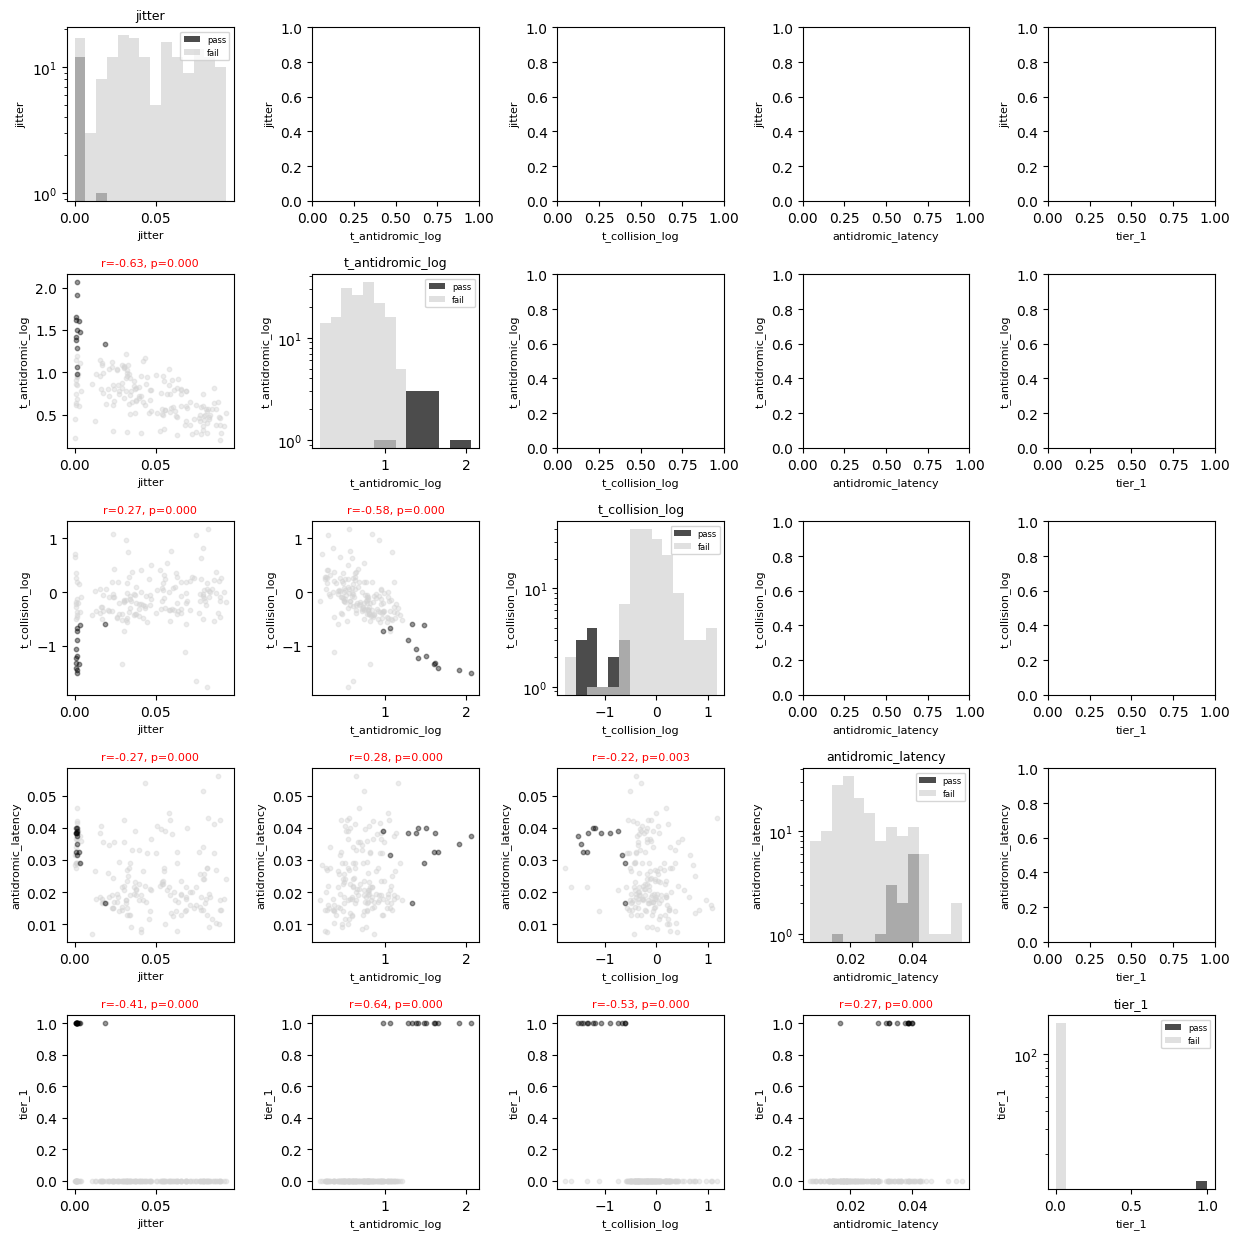

In [15]:

# Drop rows with any NaNs in the selected columns
data = combined_df[col_to_plot].dropna()
color_code = (data['jitter']<0.010) & (data['antidromic_latency']>0.02)
color_code = data['tier_1'].values > 0

n = len(col_to_plot)
fig, axes = plt.subplots(n, n, figsize=(2.5 * n, 2.5 * n))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        x = data[col_to_plot[j]].values
        y = data[col_to_plot[i]].values
        
        if i == j:
            # diagonal: histogram
            bins = np.linspace(np.min(x), np.max(x), 15)
            ax.hist(x[color_code], bins=bins, color='k', alpha=0.7, label='pass', density=False)
            ax.hist(x[~color_code], bins=bins, color='lightgray', alpha=0.7, label='fail', density=False)
            # change y to log scale
            ax.set_yscale('log')
            ax.set_title(col_to_plot[i], fontsize=9)
            ax.legend(fontsize=6)
        elif i > j:
            # scatter plot
            
            ax.scatter(x[~color_code], y[~color_code], color='lightgray', alpha=0.4, s=10)
            ax.scatter(x[color_code], y[color_code], color='k', alpha=0.4, s=10)
            
            
            # compute Pearson correlation and p-value
            if np.isfinite(x).all() and np.isfinite(y).all() and len(x) > 1:
                r, p = pearsonr(x, y)
                color = 'red' if p < 0.05 else 'black'
                ax.set_title(f"r={r:.2f}, p={p:.3f}", color=color, fontsize=8)
            else:
                ax.set_title("r=NaN", color='black', fontsize=8)
        
        # Add x and y axis labels for every subplot
        ax.set_xlabel(col_to_plot[j], fontsize=8)
        ax.set_ylabel(col_to_plot[i], fontsize=8)

plt.tight_layout()
save_panels(fig, target_folder, 'antidromic_quality_metrics_matrix', ['FigureS13k', 'FigureS13l'], exts=('pdf', 'svg'), dpi=300)
# ---- panel CSVs (rule 8 histogram: raw values per pass/fail series; rule 9: S13k=all metrics, S13l=jitter) ----
_d = combined_df[col_to_plot].dropna()
_cc = _d['tier_1'].values > 0
_allm = {}
for _col in col_to_plot:
    _allm[f'{_col}_pass'] = _d[_col].values[_cc]
    _allm[f'{_col}_fail'] = _d[_col].values[~_cc]
save_panel_csv(columns_to_df(**_allm), target_folder, 'antidromic_quality_metrics_matrix', ['FigureS13k'])
save_panel_csv(columns_to_df(jitter_pass=_d['jitter'].values[_cc], jitter_fail=_d['jitter'].values[~_cc]), target_folder, 'antidromic_quality_metrics_matrix', ['FigureS13l'])
# plt.show()
##FigureS13k##
##FigureS13l##

## Anatomical Visualization Preparation

Load 3D mesh data and prepare coordinate transformations for plotting neuron locations in Common Coordinate Framework (CCF) space. The LC core mesh provides anatomical context for spatial distributions.

In [16]:
from matplotlib.colors import Normalize
ml, ap, dv = 0, 1, 2
planes = {'sag': [ap, dv], 'hor': [ml, ap], 'cor': [ml, dv]}
bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # in mm
mesh_file = os.path.join(capsule_dirs["data_dir"], 'LC_percentile_meshes', 'core_mesh.obj')
norm = Normalize(vmin=0, vmax=1)
mesh = load_mesh(mesh_file)
mesh_vertices = np.array(mesh.vertices)
mesh_vertices = mesh_vertices/1000

mesh_vertices_mm = mesh_vertices.copy()
mesh_vertices_mm[:, 2] = -mesh_vertices_mm[:, 2]
mesh_vertices_mm[:, 0] = -mesh_vertices_mm[:, 0]
# mesh_vertices_mm = mesh_vertices[:, [0, 1, 2]]
mesh_vertices_mm = mesh_vertices_mm - bregma_LPS_mm
blue_white_red = LinearSegmentedColormap.from_list(
    'blue_white_red',
    [(0, 'red'), (0.5, 'white'), (1.0, 'blue')]
)

In [17]:
# plt.scatter(np.log(combined_df['collision_pvalue'] + 1e-20), np.log(combined_df['p_collision'] + 1e-20), c = combined_df['t_auto_inhi'], alpha=0.4)
# plt.plot([np.min(np.log(combined_df['collision_pvalue'] + 1e-20)), np.max(np.log(combined_df['collision_pvalue'] + 1e-20))],
#             [np.min(np.log(combined_df['collision_pvalue'] + 1e-20)), np.max(np.log(combined_df['collision_pvalue'] + 1e-20))], color='red')
# plt.colorbar(label='t_antidromic')
# plt.xlabel('test_log(collision_pvalue)')
# plt.ylabel('regression_log(p_collision)')

## Plot in 2D ccf space

### Spatial Distribution of Projection Neurons

Visualize the anatomical distribution of identified projection neurons across three anatomical planes (sagittal, horizontal, coronal). Neurons are color-coded by classification tier and plotted relative to the LC core mesh to reveal spatial organization patterns.

['/root/capsule/scratch/results/manuscript/figures/F_antidromic/FigureS13m_antidromic_spatial_basic_ephys.csv']

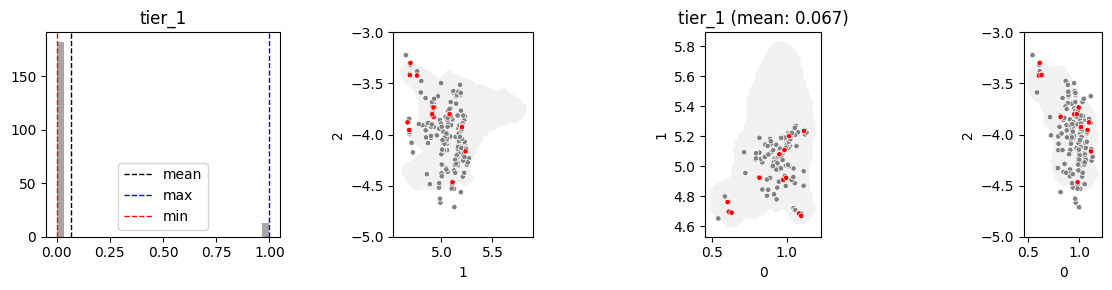

In [18]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.ndimage import binary_dilation
from skimage.measure import find_contours

features_to_plot = ['t_antidromic', 't_collision', 'jitter', 't_auto_inhi', 'short', 'tier_1', 'tier_2', 'tier_1_long', 'tier_2_long', 'p_collision']
features_to_plot = ['tier_1']

fig, axes = plt.subplots(len(features_to_plot), 4, figsize=(12, 3 * len(features_to_plot)))
axes = np.atleast_2d(axes)

# --- 3D anatomical points ---
ccfs = combined_df[['x_ccf', 'y_ccf', 'z_ccf']].values
bregma_LPS_mm = np.array([-5.7, 5.4, -0.45])  # in mm
ccfs = ccfs - bregma_LPS_mm
ml, ap, dv = 0, 1, 2
ccfs[:, ml] = np.abs(ccfs[:, ml])  # mirror ML to left hemisphere

mesh_contours = {
    plane_name: project_to_plane(mesh_vertices_mm, plane_axes, pitch=0.02, margin=0.5)
    for plane_name, plane_axes in planes.items()
}

for ind, feature in enumerate(features_to_plot):
    color = combined_df[feature].values.astype(float)
    color_reg = color.copy()

    # === Normalize colors to 0–1 ===
    if np.any(color_reg < 0) and np.any(color_reg > 0):
        amp_cut = np.nanquantile(np.abs(color_reg), 0.975)
        color_reg = 0.5 + 0.5 * color_reg / amp_cut
        color_reg = np.clip(color_reg, 0, 1)
        center_line = 0
        upper_limit = amp_cut
        lower_limit = -amp_cut
        # === Colormap ===
        custom_cmap = LinearSegmentedColormap.from_list(
            'blue_white_red', [(0.0, 'red'), (0.5, 'white'), (1.0, 'blue')]
        )
    else:
        amp_cut = np.nanquantile(np.abs(color_reg), 0.975)
        color_reg = np.abs(color_reg)
        color_reg = (color_reg - np.nanmin(color_reg))/(amp_cut - np.nanmin(color_reg))
        color_reg = np.clip(color_reg, 0, 1)
        center_line = np.nanmean(color)
        lower_limit = np.nanmin(np.abs(color)) * np.sign(center_line)
        upper_limit = amp_cut * np.sign(center_line)
        # === Colormap ===
        custom_cmap = LinearSegmentedColormap.from_list('gray_red', [(0.0, 'gray'), (1.0, 'red')])

    color_reg[np.isnan(color_reg)] = 0.5

    # === Histogram of feature values ===
    ax_hist = axes[ind, 0]
    ax_hist.hist(combined_df[feature].values, bins=30, color='gray', alpha=0.7)
    ax_hist.set_title(feature)
    ax_hist.axvline(center_line, color='k', linestyle='--', linewidth=1, label='mean')
    ax_hist.axvline(upper_limit, color='blue', linestyle='--', linewidth=1, label = 'max')
    ax_hist.axvline(lower_limit, color='red', linestyle='--', linewidth=1, label = 'min')
    ax_hist.legend()

    # # === Compute alpha scaling from rho ===
    # alpha_scale = combined_df['rho'].values[mask]
    # alpha_scale = np.sqrt(alpha_scale)               # soften scaling
    # alpha_scale = np.clip(alpha_scale, 0.2, 0.8)     # prevent extremes

    # === Sort and filter ===
    sort_ind = np.argsort(color_reg)
    ccfs_plot = ccfs[sort_ind]
    color_reg_plot = color_reg[sort_ind]
    # alpha_scale_plot = alpha_scale[sort_ind]

    # # === Precompute RGBA facecolors ===
    rgba_colors = custom_cmap(color_reg_plot)
    # rgba_colors[:, -1] = alpha_scale_plot  # inject alpha per point

    # === 2D plane projections ===
    for plane, ax in zip(planes.keys(), axes[ind, 1:]):
        # background mesh outline
        # ax.scatter(
        #     mesh_vertices_mm[:, planes[plane][0]],
        #     mesh_vertices_mm[:, planes[plane][1]],
        #     color='k', alpha=0.4, s=0.05, edgecolors='none'
        # )
        for c in mesh_contours[plane]:
            ax.fill(c[:, 0], c[:, 1], color='lightgray', alpha=0.3, linewidth=0)

        # scatter the points (alpha-scaled)
        sc = ax.scatter(
            ccfs_plot[:, planes[plane][0]],
            ccfs_plot[:, planes[plane][1]],
            facecolors=rgba_colors,
            edgecolors=[1, 1, 1],
            linewidths=0.5,
            alpha = 1,
            s=15
        )

        if plane == 'hor':
            value_mean = np.nanmean(combined_df[feature].values)
            ax.set_title(f'{feature} (mean: {value_mean:.3f})')
        ax.set_xlabel(planes[plane][0])
        ax.set_ylabel(planes[plane][1])
        ax.set_aspect('equal')

        if planes[plane][1] == dv:
            ax.set_ylim([-5, -3])

plt.tight_layout()
save_panels(fig, target_folder, f'antidromic_spatial_{criteria_name}', ['FigureS13m'], exts=('pdf',), bbox_inches='tight', dpi=300)
# ---- panel CSV (rule 1: scatter, NE neurons in LC space colored by tier_1) ----
save_panel_csv(columns_to_df(x_ccf_mm=ccfs[:, 0], y_ccf_mm=ccfs[:, 1], z_ccf_mm=ccfs[:, 2], tier_1=combined_df['tier_1'].values.astype(float)), target_folder, f'antidromic_spatial_{criteria_name}', ['FigureS13m'])

# plt.close()
##FigureS13m##


## Collect figures from individual neurons (optional)

In [19]:
# # grab all figures and save 
# import shutil
# curr_target_folder = os.path.join(target_folder, 'antidromic_figures')
# # remove before copying
# shutil.rmtree(curr_target_folder, ignore_errors=True)
# os.makedirs(curr_target_folder, exist_ok=True)
# tiers = ['tier_1', 'tier_2']
# sub_classes = ['long', 'short']
# for tier in tiers:
#     for sub_class in sub_classes:
#         shutil.rmtree(path=os.path.join(curr_target_folder, tier, sub_class), ignore_errors=True)
#         os.makedirs(os.path.join(curr_target_folder, tier, sub_class), exist_ok=True)

# null_folder = os.path.join(curr_target_folder, 'null_figures')
# os.makedirs(null_folder, exist_ok=True)

# target_folder_t1 = os.path.join(curr_target_folder, 'tier_1', 'short')
# target_folder_t2 = os.path.join(curr_target_folder, 'tier_2', 'short')
# target_folder_t1_long = os.path.join(curr_target_folder, 'tier_1', 'long')
# target_folder_t2_long = os.path.join(curr_target_folder, 'tier_2', 'long')

# for row_ind, row in combined_df.iterrows():
#     session = row['session']
#     unit = row['unit']
#     tier_1 = row['tier_1']
#     tier_2 = row['tier_2']
#     tier_1_long = row['tier_1_long']
#     tier_2_long = row['tier_2_long']

#     # find corresponding row in combined_tagged_units_filtered to get isi_violations
#     combined_tagged_units_row = combined_tagged_units_filtered[
#         (combined_tagged_units_filtered['session'] == session) &
#         (combined_tagged_units_filtered['unit'] == unit)
#     ]
#     if combined_tagged_units_row.empty:
#         print(f'No matching row found in combined_tagged_units_filtered for {session} unit {unit}. Skipping.')
#         isi_v = 'NaN'
#     else:
#         isi_v = combined_tagged_units_row.iloc[0]['isi_violations']
    
#     source_folder = os.path.join(session_dirs(session)['opto_dir_curated'], 'figures', 'antidromic')
#     figure_name = f'{session}_unit{unit}_opto_responses.pdf'
#     source_path =  os.path.join(source_folder, figure_name)
#     if not os.path.exists(source_folder):
#         figure_name = f'{session}_unit{unit}.0_opto_responses.pdf'
#         source_path =  os.path.join(source_folder, figure_name)
    
#     if os.path.exists(source_path):
#         print(f'Found figure for {session} unit {unit}.')
#         if tier_1_long:
#             if tier_1:
#                 curr_target_folder = target_folder_t1
#                 print(f'Copying {figure_name} to tier_1 folder...')
#             else:
#                 curr_target_folder = target_folder_t1_long
#                 print(f'Copying {figure_name} to tier_1_long folder...')
#         elif tier_2_long:
#             if tier_2:
#                 curr_target_folder = target_folder_t2
#                 print(f'Copying {figure_name} to tier_2 folder...')
#             else:
#                 curr_target_folder = target_folder_t2_long
#                 print(f'Copying {figure_name} to tier_2_long folder...')
#         else:
#             curr_target_folder = null_folder
#             print(f'Copying {figure_name} to null folder...')
#         if not np.isnan(row["jitter"]):
#             jitter = int(round(1000*row["jitter"]))
#         else:
#             jitter = 'NA'
        
#         if not np.isnan(row["antidromic_latency"]):
#             antidromic_latency = int(round(1000*row["antidromic_latency"]))
#         else:
#             antidromic_latency = 'NA'
#         shutil.copy(source_path, os.path.join(curr_target_folder, f'{session}_unit_{unit}_col_{row["t_collision"]:.1f}_anti_{row["t_antidromic"]:.1f}_lat_{antidromic_latency}_jitter_{jitter}_isi_{isi_v:.2f}.pdf'
# ))
#     else:
#         print(f'Figure not found for {session} unit {unit}.')

In [20]:
# # combine pdfs
# curr_target_folder = os.path.join(target_folder, 'antidromic_figures')
# for tier in tiers:
#     for sub_class in sub_classes:
#         input_folder = os.path.join(curr_target_folder, tier, sub_class)
#         output_pdf = os.path.join(curr_target_folder, f'antidromic_{focus}_{tier}_{sub_class}.pdf')
#         combine_pdf_big(input_folder, output_pdf)
#         print(f'Combined PDF saved to {output_pdf}')